In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
data=pd.read_csv(r"C:\Users\miriy\Downloads\online_store_sales_500.csv")
data

,Order_ID,Order_Date,Customer_ID,Customer_Name,City,Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Status
0,ORD0001,2025-03-13,C161,Nigar,Ganja,Clothing,Backpack,3,45.27,0.00,Bank Transfer,Cancelled
1,ORD0002,2025-12-10,C130,Elvin,Ganja,Clothing,Sneakers,4,18.40,0.00,Online Payment,Completed
2,ORD0003,2026-04-20,C159,Emil,Ganja,Books,AI Book,4,9.20,0.20,Bank Transfer,Returned
3,ORD0004,2026-05-20,C103,Nigar,Sumqayit,Home,Air Fryer,5,161.56,0.05,Cash,Completed
4,ORD0005,2025-12-12,C153,Murad,Lankaran,Electronics,Smart Watch,4,262.21,0.05,Bank Transfer,Completed
...,...,...,...,...,...,...,...,...,...,...,...,...
495,ORD0496,2025-11-12,C154,Lala,Lankaran,Furniture,Office Chair,4,248.41,0.10,Card,Completed
496,ORD0497,2025-12-27,C142,Emil,Mingachevir,Clothing,Jeans,5,53.50,0.10,Online Payment,Completed
497,ORD0498,2025-06-11,C132,Zehra,Baku,Home,Vacuum Cleaner,2,224.23,0.05,Card,Completed
498,ORD0499,2026-05-20,C198,Orxan,Lankaran,Furniture,Office Chair,2,229.27,0.05,Online Payment,Completed


In [5]:
data.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,City,Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Status
0,ORD0001,2025-03-13,C161,Nigar,Ganja,Clothing,Backpack,3,45.27,0.00,Bank Transfer,Cancelled
1,ORD0002,2025-12-10,C130,Elvin,Ganja,Clothing,Sneakers,4,18.40,0.00,Online Payment,Completed
2,ORD0003,2026-04-20,C159,Emil,Ganja,Books,AI Book,4,9.20,0.20,Bank Transfer,Returned
3,ORD0004,2026-05-20,C103,Nigar,Sumqayit,Home,Air Fryer,5,161.56,0.05,Cash,Completed
4,ORD0005,2025-12-12,C153,Murad,Lankaran,Electronics,Smart Watch,4,262.21,0.05,Bank Transfer,Completed


In [6]:
data.shape

(500, 12)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        500 non-null    object 
 1   Order_Date      500 non-null    object 
 2   Customer_ID     500 non-null    object 
 3   Customer_Name   495 non-null    object 
 4   City            500 non-null    object 
 5   Category        500 non-null    object 
 6   Product         500 non-null    object 
 7   Quantity        500 non-null    int64  
 8   Unit_Price      500 non-null    float64
 9   Discount        500 non-null    float64
 10  Payment_Method  495 non-null    object 
 11  Order_Status    500 non-null    object 
dtypes: float64(2), int64(1), object(9)
memory usage: 47.0+ KB


In [8]:
data.describe()

,Quantity,Unit_Price,Discount
count,500.000000,500.000000,500.000000
mean,3.088000,132.300260,0.062600
std,1.410047,103.166233,0.058806
min,1.000000,8.300000,0.000000
25%,2.000000,43.552500,0.000000
50%,3.000000,110.035000,0.050000
75%,4.000000,196.482500,0.100000
max,5.000000,449.060000,0.200000


In [11]:
data.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Customer_Name     5
City              0
Category          0
Product           0
Quantity          0
Unit_Price        0
Discount          0
Payment_Method    5
Order_Status      0
dtype: int64

In [12]:
data.duplicated().sum()

np.int64(0)

In [13]:
data["Order_ID"].duplicated().sum()

np.int64(0)

In [14]:
data.dtypes

Order_ID           object
Order_Date         object
Customer_ID        object
Customer_Name      object
City               object
Category           object
Product            object
Quantity            int64
Unit_Price        float64
Discount          float64
Payment_Method     object
Order_Status       object
dtype: object

In [18]:
data["Order_Date"]=pd.to_datetime(data["Order_Date"])
data["Order_Date"].dtype

dtype('<M8[ns]')

In [19]:
data["Year"]=data["Order_Date"].dt.year

In [20]:
data["Month"]=data["Order_Date"].dt.month

In [21]:
data.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,City,Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Status,Year,Month
0,ORD0001,2025-03-13,C161,Nigar,Ganja,Clothing,Backpack,3,45.27,0.00,Bank Transfer,Cancelled,2025,3
1,ORD0002,2025-12-10,C130,Elvin,Ganja,Clothing,Sneakers,4,18.40,0.00,Online Payment,Completed,2025,12
2,ORD0003,2026-04-20,C159,Emil,Ganja,Books,AI Book,4,9.20,0.20,Bank Transfer,Returned,2026,4
3,ORD0004,2026-05-20,C103,Nigar,Sumqayit,Home,Air Fryer,5,161.56,0.05,Cash,Completed,2026,5
4,ORD0005,2025-12-12,C153,Murad,Lankaran,Electronics,Smart Watch,4,262.21,0.05,Bank Transfer,Completed,2025,12


In [25]:
data["General_Price"]=data["Quantity"]*data["Unit_Price"]
data["Discounted_Price"]=data["General_Price"]*data["Discount"]
data["Net_Sales"]=data["General_Price"]-data["Discounted_Price"]
data.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,City,Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Status,Year,Month,General_Price,Discounted_Price,Net_Sales
0,ORD0001,2025-03-13,C161,Nigar,Ganja,Clothing,Backpack,3,45.27,0.00,Bank Transfer,Cancelled,2025,3,135.81,0.000,135.810
1,ORD0002,2025-12-10,C130,Elvin,Ganja,Clothing,Sneakers,4,18.40,0.00,Online Payment,Completed,2025,12,73.60,0.000,73.600
2,ORD0003,2026-04-20,C159,Emil,Ganja,Books,AI Book,4,9.20,0.20,Bank Transfer,Returned,2026,4,36.80,7.360,29.440
3,ORD0004,2026-05-20,C103,Nigar,Sumqayit,Home,Air Fryer,5,161.56,0.05,Cash,Completed,2026,5,807.80,40.390,767.410
4,ORD0005,2025-12-12,C153,Murad,Lankaran,Electronics,Smart Watch,4,262.21,0.05,Bank Transfer,Completed,2025,12,1048.84,52.442,996.398


In [26]:
data["Order_ID"].nunique()

500

In [27]:
data["Customer_ID"].nunique()

98

In [28]:
data["Quantity"].sum()

np.int64(1544)

In [29]:
data["Net_Sales"].sum()

np.float64(190699.7715)

In [30]:
data["Net_Sales"].mean()

np.float64(381.399543)

In [34]:
data.groupby("Category")["Net_Sales"].sum().sort_values(ascending=False)

Category
Electronics    57906.0960
Home           51080.5380
Furniture      42958.4820
Clothing       27628.4465
Books          11126.2090
Name: Net_Sales, dtype: float64

In [41]:
data.groupby("Category").agg(
    Total_Sales=("Net_Sales","sum"),
    Total_Quantity=("Quantity","sum"),
    Avg_Sales=("Net_Sales","mean")
)


,Total_Sales,Total_Quantity,Avg_Sales
Category,,,
Books,11126.2090,348,93.497555
Clothing,27628.4465,322,265.658139
Electronics,57906.0960,287,697.663807
Furniture,42958.4820,249,517.572072
Home,51080.5380,338,460.185027


In [40]:
data.groupby("Category")["Net_Sales"].agg(["sum","mean","min","max"])

,sum,mean,min,max
Category,,,,
Books,11126.2090,93.497555,6.640,291.60
Clothing,27628.4465,265.658139,46.278,873.75
Electronics,57906.0960,697.663807,47.730,2099.31
Furniture,42958.4820,517.572072,49.869,1580.40
Home,51080.5380,460.185027,15.138,1480.80


In [42]:
data.groupby("City")["Net_Sales"].sum().sort_values()

City
Sumqayit       26038.7950
Mingachevir    28439.3105
Ganja          31357.1405
Shaki          32185.8415
Baku           35437.2515
Lankaran       37241.4325
Name: Net_Sales, dtype: float64

In [45]:
data.groupby("City").agg(
    Total_Sales=("Net_Sales", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Avg_Sales=("Net_Sales", "mean")
).sort_values("Total_Sales", ascending=False)

,Total_Sales,Total_Quantity,Avg_Sales
City,,,
Lankaran,37241.4325,247,454.163811
Baku,35437.2515,306,373.023700
Shaki,32185.8415,222,417.997942
Ganja,31357.1405,267,368.907535
Mingachevir,28439.3105,268,315.992339
Sumqayit,26038.7950,234,366.743592


In [46]:
data.groupby("Payment_Method")["Net_Sales"].sum().sort_values(ascending=False)

Payment_Method
Online Payment    51400.5935
Cash              48082.2135
Card              46434.4225
Bank Transfer     43334.2630
Name: Net_Sales, dtype: float64

In [47]:
data["Order_Status"].value_counts()

Order_Status
Completed    330
Returned      89
Cancelled     81
Name: count, dtype: int64

In [59]:
data.groupby("Product")["Quantity"].sum().sort_values().head(10)

Product
Keyboard          31
Monitor Stand     33
Desk              43
Backpack          46
Wireless Mouse    46
Bookshelf         48
Kettle            53
T-Shirt           58
Office Chair      59
Smart Watch       61
Name: Quantity, dtype: int64

In [60]:
data.groupby("Product")["Net_Sales"].sum().sort_values(ascending=False).head(10)

Product
Headphones        18280.2625
Smart Watch       13781.2380
Power Bank        12635.5760
Blender           12432.6720
Air Fryer         10983.7290
Office Chair      10846.1925
Table Lamp        10536.3630
Vacuum Cleaner    10345.3855
Bookshelf          9575.7785
Coffee Maker       9330.9635
Name: Net_Sales, dtype: float64

In [61]:
data.groupby(["Year","Month"])["Net_Sales"].sum()

Year  Month
2025  1        13817.3100
      2         6346.9850
      3         9243.3335
      4         6919.0560
      5         9051.3325
      6         7184.6960
      7        11771.6905
      8         9391.9910
      9        11431.6510
      10        8491.2410
      11       11315.9270
      12        7343.1590
2026  1         9669.0170
      2         3676.2460
      3        11726.9390
      4        11245.4210
      5        13978.2110
      6         8644.0065
      7        10194.0295
      8         9257.5290
Name: Net_Sales, dtype: float64

In [62]:
sales_by_category=data.groupby("Category")["Net_Sales"].sum().sort_values(ascending=False)

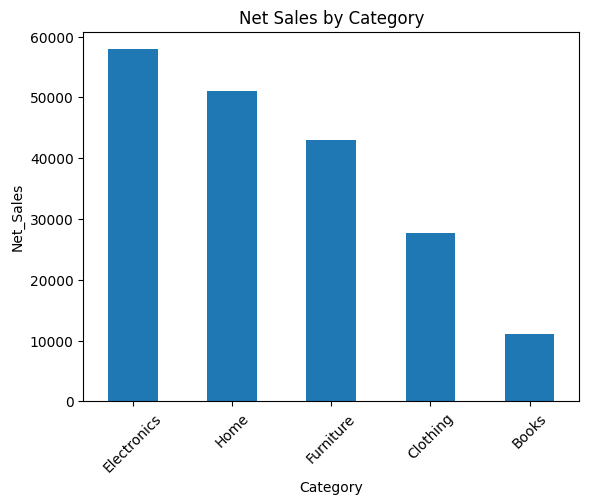

In [63]:
sales_by_category.plot(kind="bar")
plt.title("Net Sales by Category")
plt.xlabel("Category")
plt.ylabel("Net_Sales")
plt.xticks(rotation=45)
plt.show()

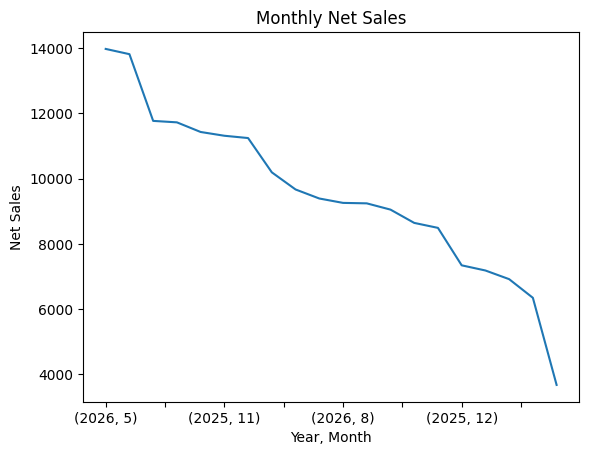

In [64]:
monthly_sales=data.groupby(["Year","Month"])["Net_Sales"].sum().sort_values(ascending=False)
monthly_sales.plot(kind="line")
plt.title("Monthly Net Sales")
plt.xlabel("Year, Month")
plt.ylabel("Net Sales")
plt.show()